# Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Load Dataset

In [2]:
file_path = Path("../dataset/credit_risk_dataset.csv")

if file_path.exists() :
    df = pd.read_csv(file_path)
    print("Load Dataset Success")
else :
    print(f"Error : {file_path} does't exist.")

Load Dataset Success


# Data Understanding

In [3]:
df.shape

(32581, 12)

In [4]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.5 MB


In [6]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [7]:
df.tail()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26
32580,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,0.15,N,30


# EDA Exploratory Data Analysis

In [8]:
# Check Missing value
print(df.isna().sum().sort_values(ascending=False).to_string())

loan_int_rate                 3116
person_emp_length              895
person_income                    0
person_age                       0
person_home_ownership            0
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0


In [9]:
# Check each row have a NaN
df[df.isna().any(axis=1)]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
39,23,71500,RENT,3.0,DEBTCONSOLIDATION,D,30000,NaN,1,0.42,N,4
50,24,78000,RENT,4.0,DEBTCONSOLIDATION,D,30000,NaN,1,0.38,Y,4
57,23,277000,OWN,3.0,PERSONAL,A,35000,NaN,0,0.13,N,4
59,24,12000,OWN,2.0,VENTURE,E,1750,NaN,0,0.15,Y,3
62,26,263000,MORTGAGE,0.0,EDUCATION,B,10000,NaN,1,0.04,N,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32547,53,4888,OWN,0.0,VENTURE,C,1400,NaN,1,0.29,Y,28
32552,65,45900,RENT,2.0,EDUCATION,C,10000,NaN,0,0.22,Y,19
32553,54,20000,RENT,2.0,MEDICAL,C,5000,NaN,0,0.25,N,28
32569,51,60000,MORTGAGE,1.0,PERSONAL,A,7500,NaN,0,0.13,N,23


In [10]:
df.duplicated().sum()

np.int64(165)

In [11]:
# Check Duplicate
duplicates = df[df.duplicated(keep=False)]

duplicates = duplicates.sort_values(by=df.columns.to_list())

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

display(duplicates)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
15944,21,8088,RENT,NaN,MEDICAL,C,1200,15.23,0,0.15,Y,2
16835,21,8088,RENT,NaN,MEDICAL,C,1200,15.23,0,0.15,Y,2
2431,21,15600,RENT,0.0,MEDICAL,A,2800,7.40,1,0.18,N,4
17758,21,15600,RENT,0.0,MEDICAL,A,2800,7.40,1,0.18,N,4
2498,21,18000,RENT,0.0,DEBTCONSOLIDATION,A,3000,7.90,1,0.17,N,2
17601,21,18000,RENT,0.0,DEBTCONSOLIDATION,A,3000,7.90,1,0.17,N,2
1778,21,20000,RENT,0.0,MEDICAL,A,2000,NaN,0,0.10,N,3
17642,21,20000,RENT,0.0,MEDICAL,A,2000,NaN,0,0.10,N,3
740,21,21600,OWN,NaN,VENTURE,A,7125,6.99,0,0.33,N,3
17283,21,21600,OWN,NaN,VENTURE,A,7125,6.99,0,0.33,N,3


loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64


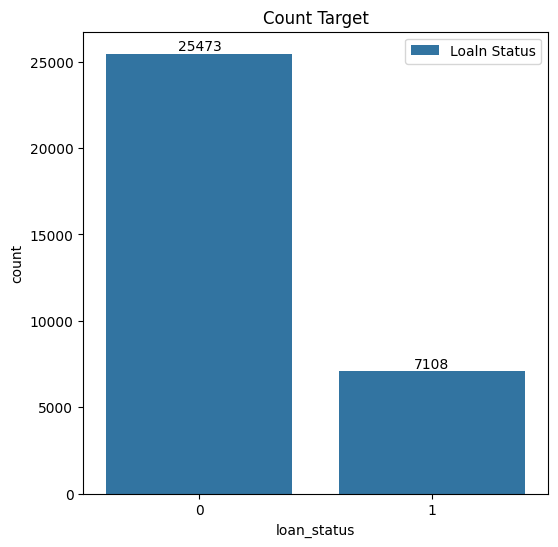

In [12]:
# Check Percentage Target, Is there an imbalance or not?
percent_target = df['loan_status'].value_counts(normalize=True) * 100
print(percent_target)
# Count Target

plt.figure(figsize=(6,6))
ax = sns.countplot(
    x=df['loan_status'],
    hue_order=['0', '1'],
    label='Loaln Status'
)
ax.bar_label(ax.containers[0])
plt.legend()
plt.title("Count Target")
plt.show()

### Interpretation Percent Target
we can see if our data have imbalance in target so we have to fix it before splitting data

# Distribution Numerical Each Feature (EDA)

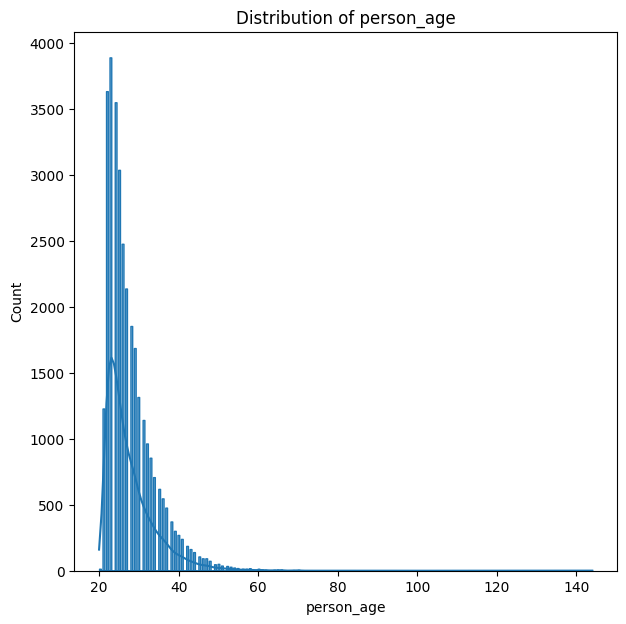

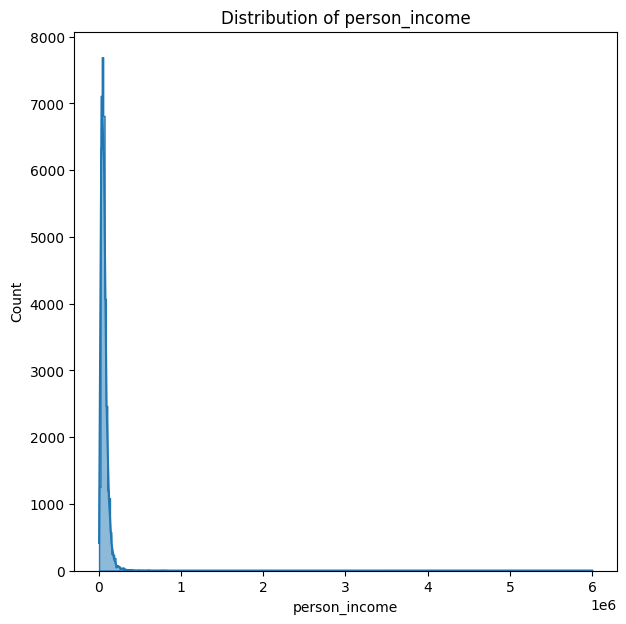

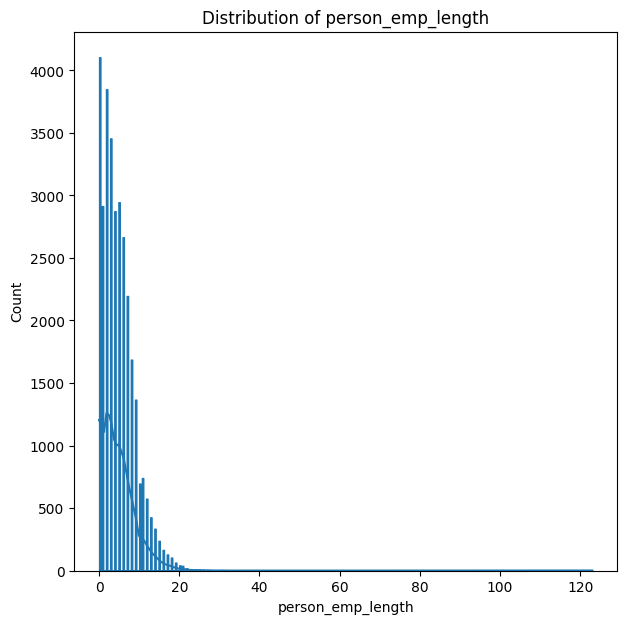

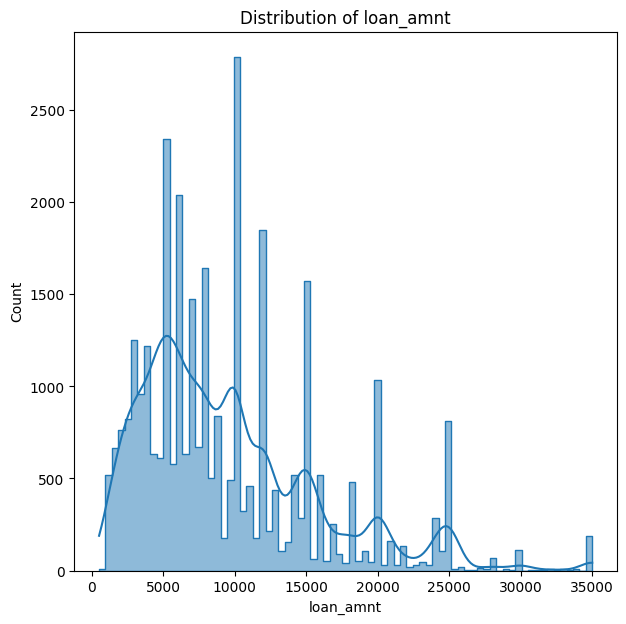

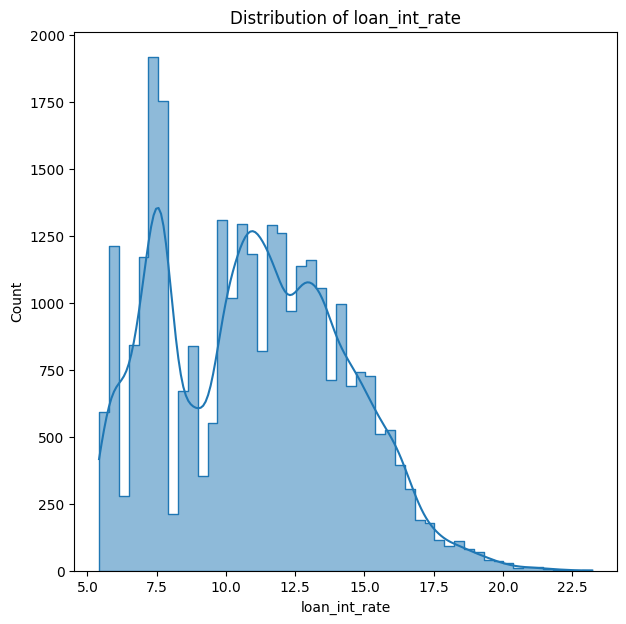

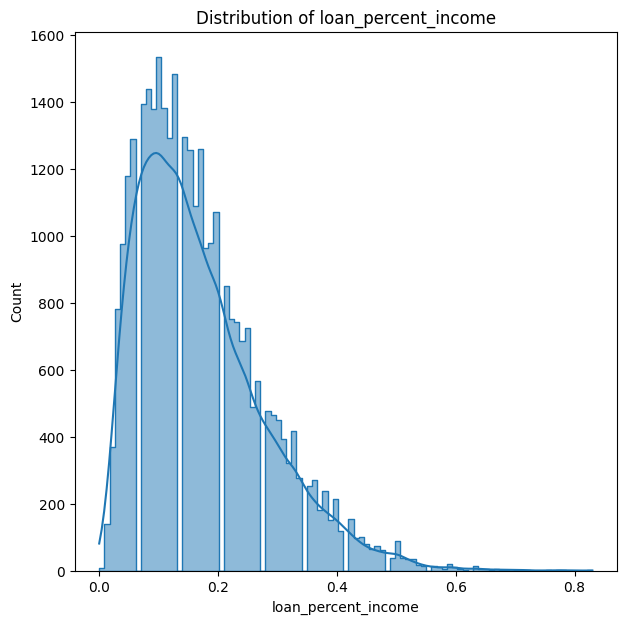

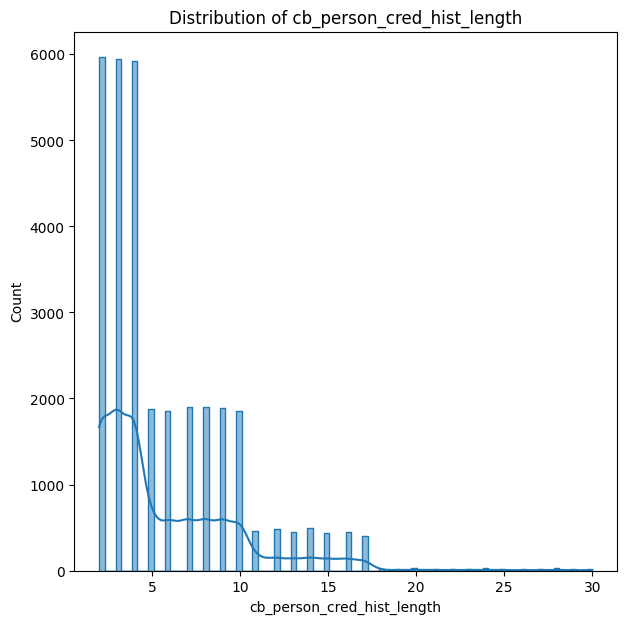

In [13]:
num_feature_dist = [
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length'
]

for feature_num in num_feature_dist :
    plt.figure(figsize=(7,7))
    sns.histplot(
        data=df,
        x=feature_num,
        kde=True,
        element='step'
    )
    plt.title(f"Distribution of {feature_num}")
    plt.show()

## Interpretation Distribution of Numerical Feature
1. Person_age = skewed right
2. person_income = skewed right
3. person_emp_length = skewed right
4. loan_amnt = Normal Distribution
5. loan_int_rate = Normal Distributons
6. loan_percent_income = skewed right but little
7. cb_person = skewed right

# Distribution Categorical Eeach Feature

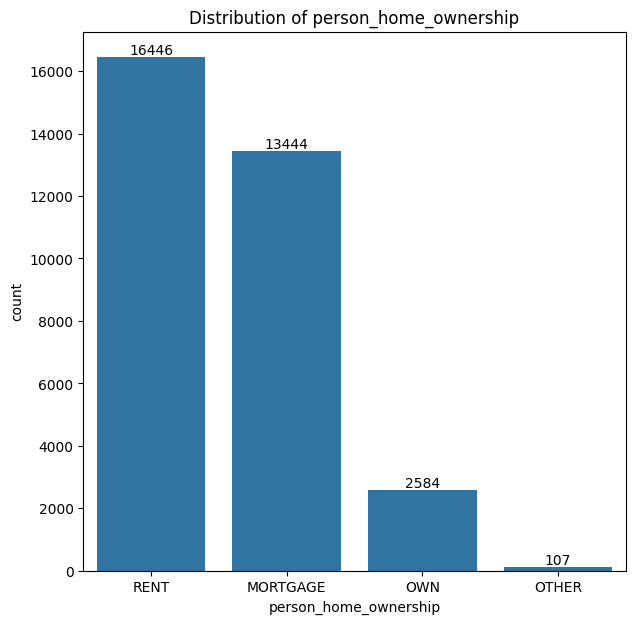

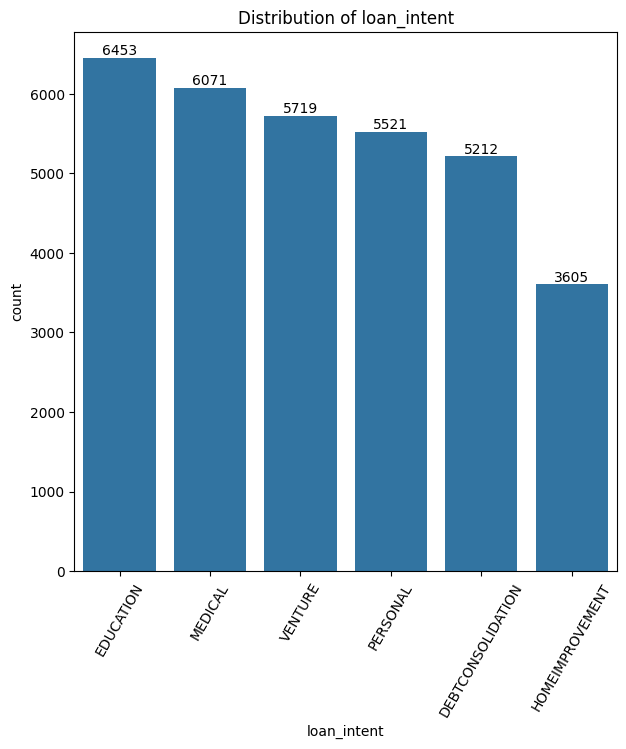

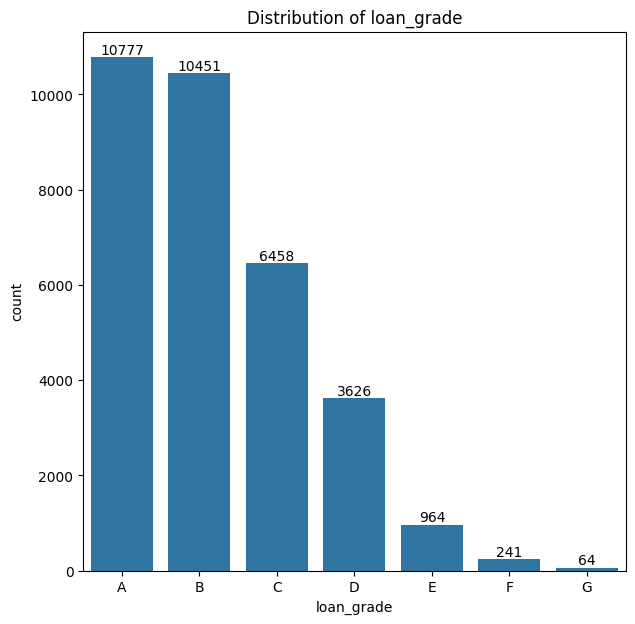

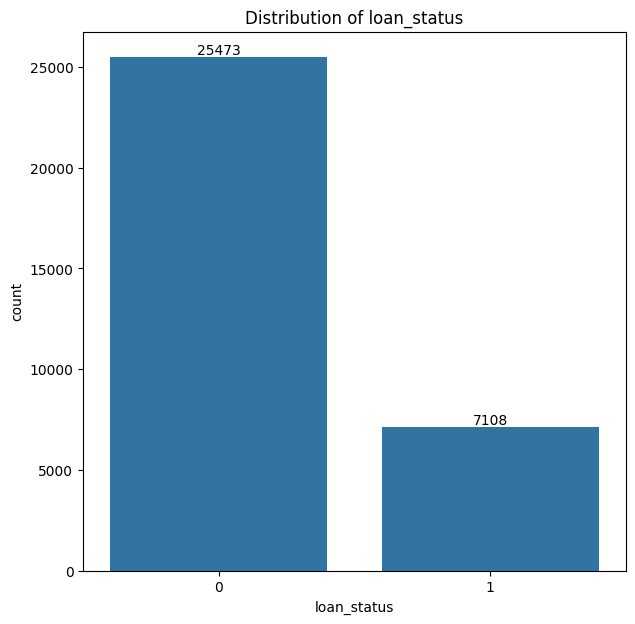

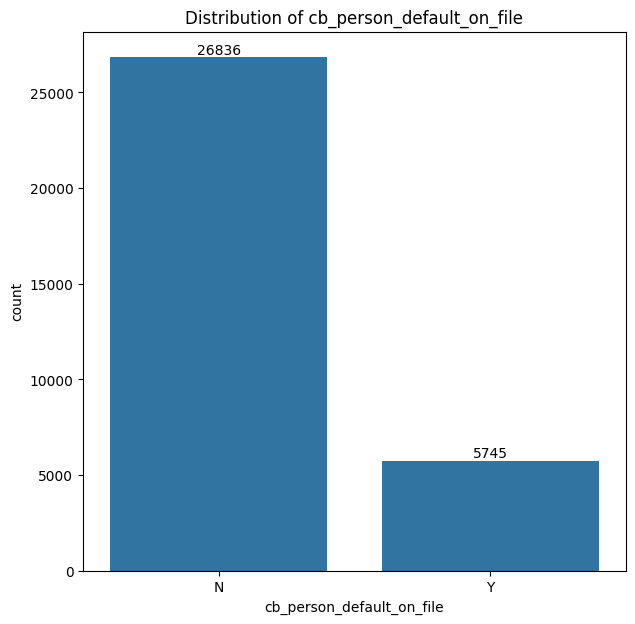

In [14]:
cat_feature_dist = [
    'person_home_ownership',
    'loan_intent',
    'loan_grade',
    'loan_status',
    'cb_person_default_on_file'
]

for feature_cat in cat_feature_dist :
    count_feature = df[feature_cat].value_counts().index
    plt.figure(figsize=(7,7))
    ax = sns.countplot(
        data=df,
        x=feature_cat,
        order=count_feature
    )
    if feature_cat == 'loan_intent' :
        plt.xticks(rotation=60)
    ax.bar_label(ax.containers[0])
    plt.title(f'Distribution of {feature_cat}')
    plt.show()

## Interpretation Distribution of Categorical Feature
1. person_home_ownership = Rent is the most of distribution
2. loan_intent = distribution looks normal because The distance isn't too far
3. loan_grade = the top is A and the G is the lowest grade
4. cb_person = N is the most freq which is good because N = 0 or through the loan

# Compare Numerical Features VS Target (loan_status)

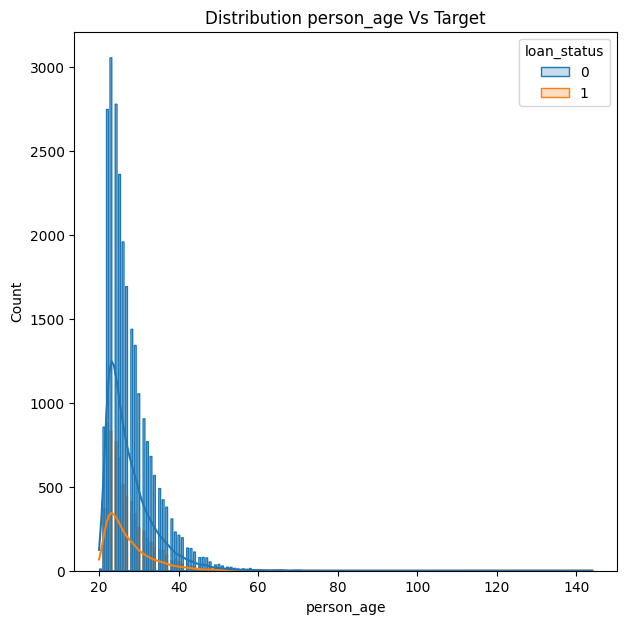

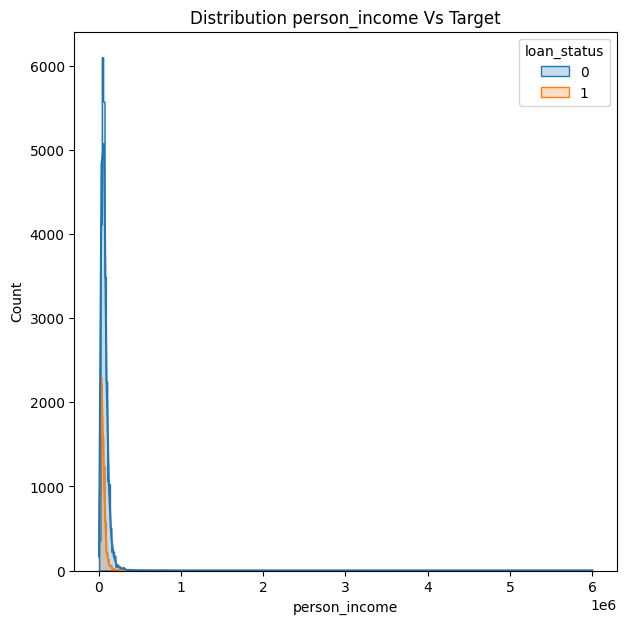

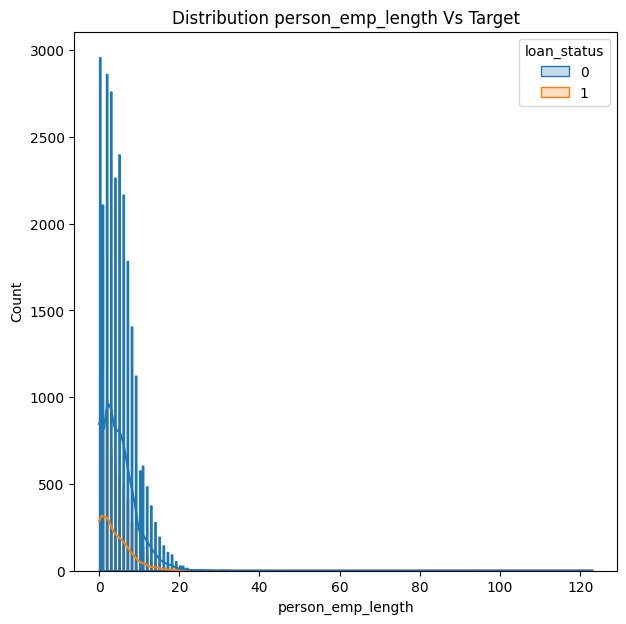

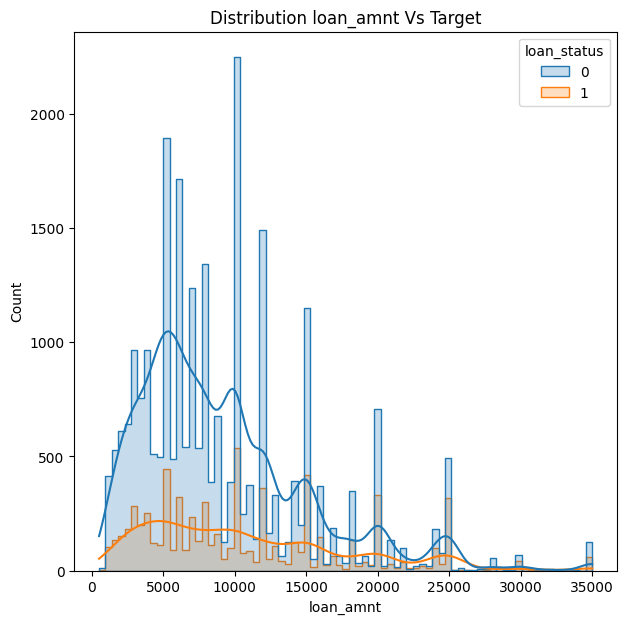

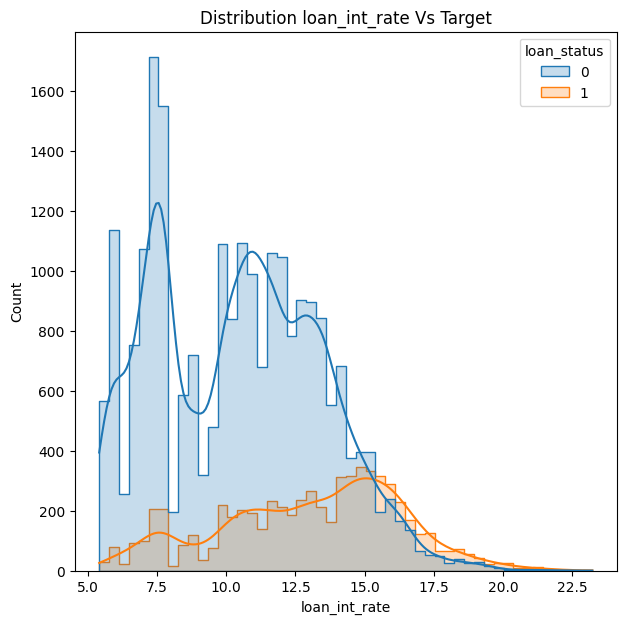

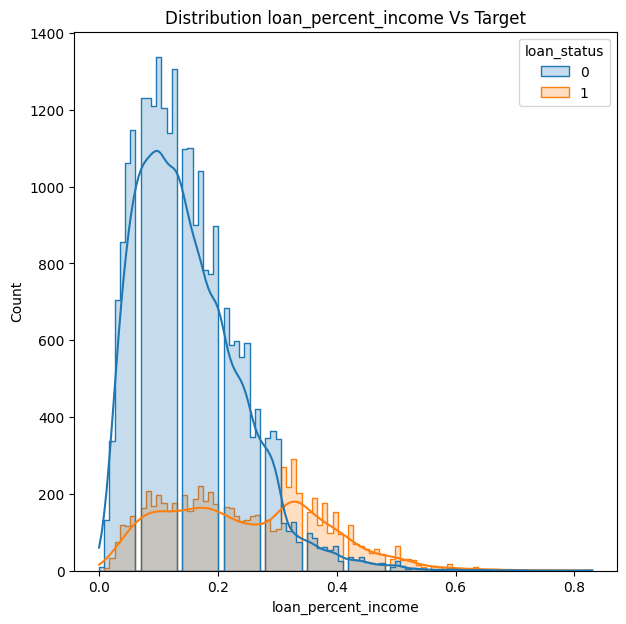

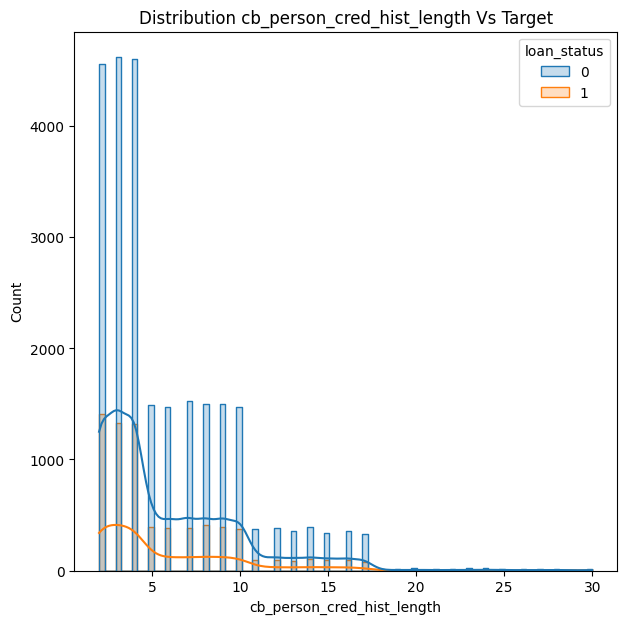

In [15]:
for feature_num_sec in num_feature_dist :
   plt.figure(figsize=(7,7))
   sns.histplot(
      data=df,
      x = feature_num_sec,
      hue = df['loan_status'],
      kde = True,
      element='step'

   ) 
   plt.title(f'Distribution {feature_num_sec} Vs Target')
   plt.show()

# Check outliner data from Numerical Features

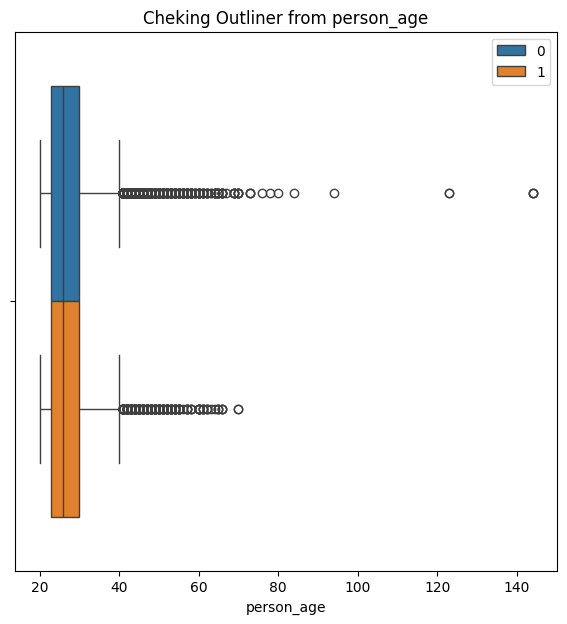

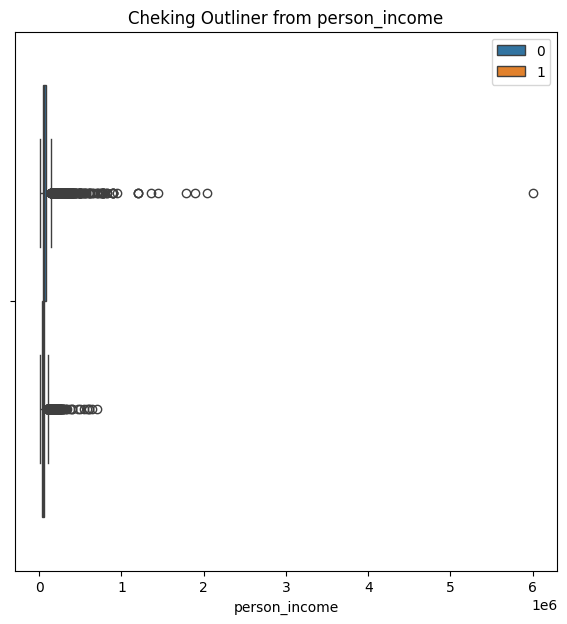

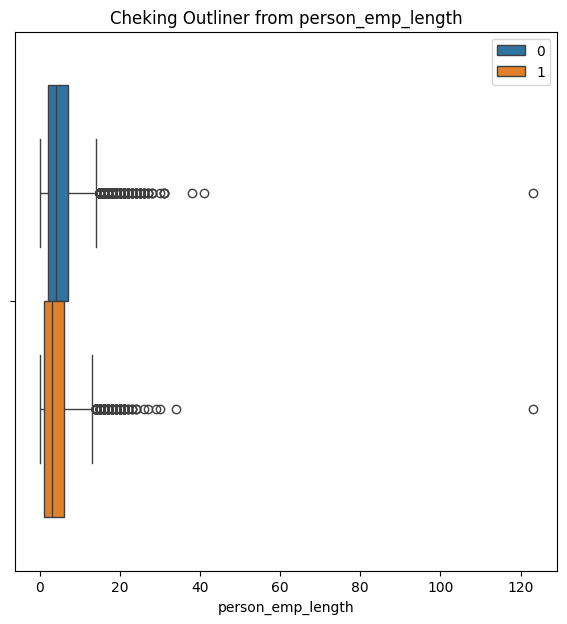

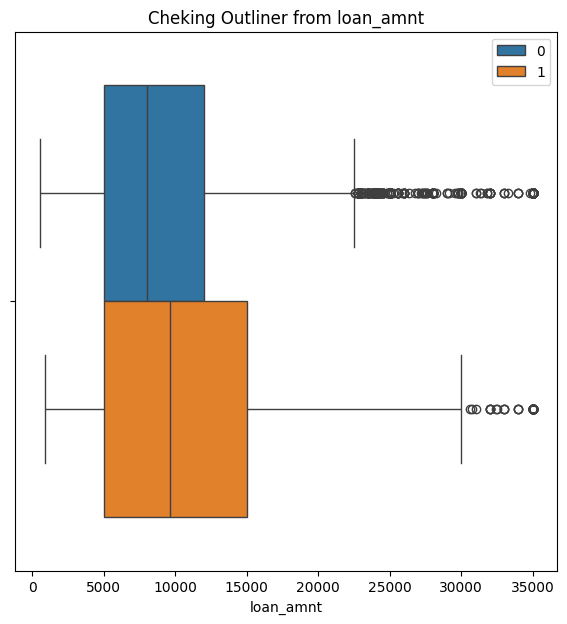

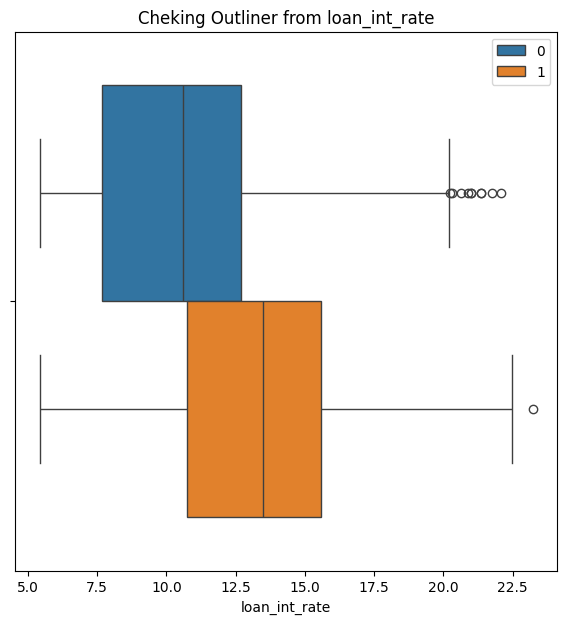

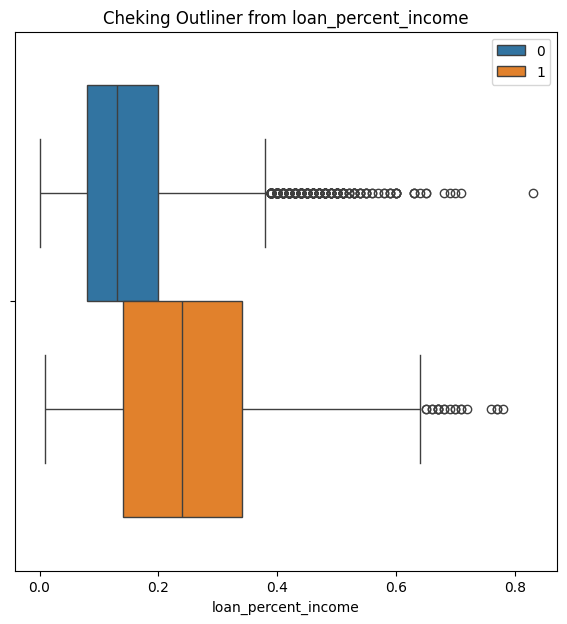

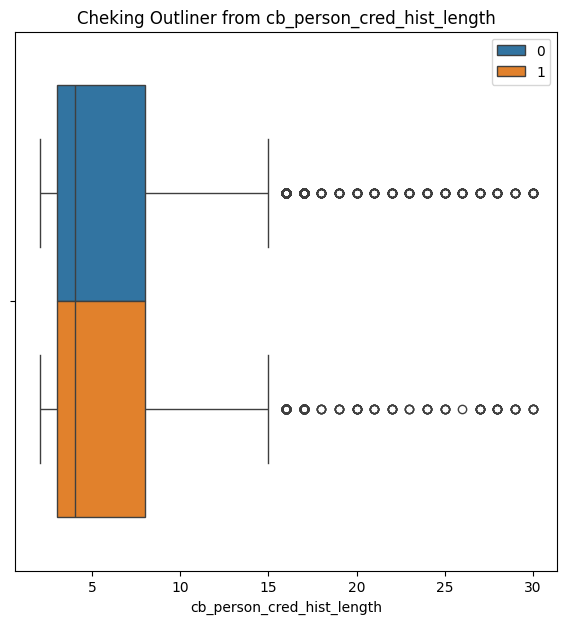

In [16]:
for col in num_feature_dist :
    plt.figure(figsize=(7,7))
    sns.boxplot(
        data= df,
        x= col,
        hue= df['loan_status']
    )
    plt.title(f"Cheking Outliner from {col}")
    plt.legend()
    plt.show()

# Check Relationshi from Numerical Features

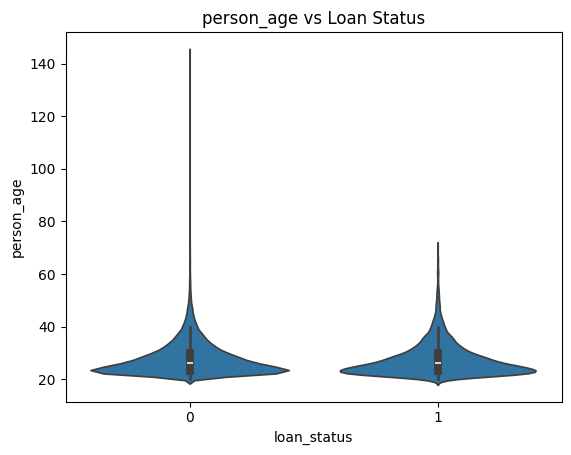

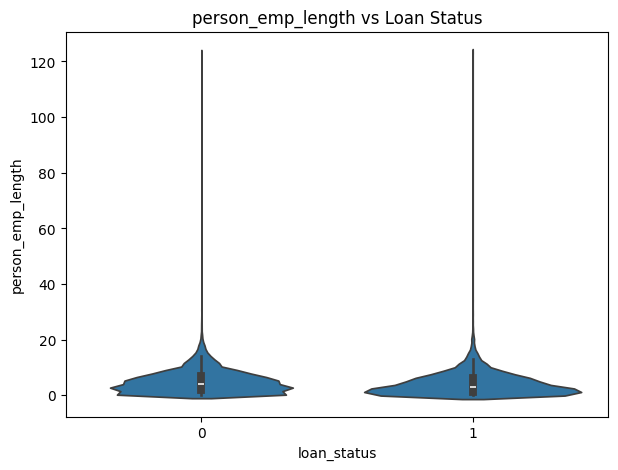

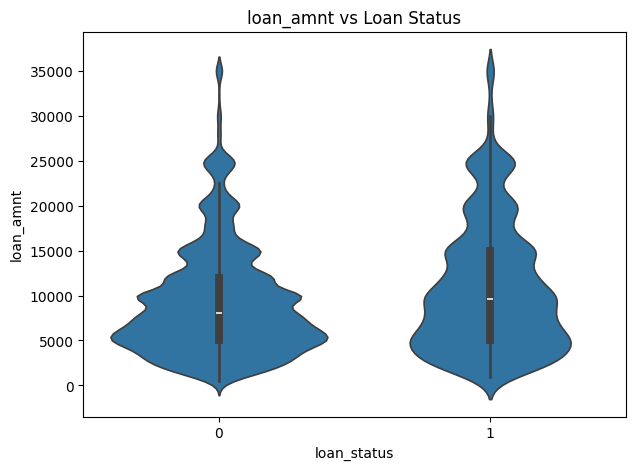

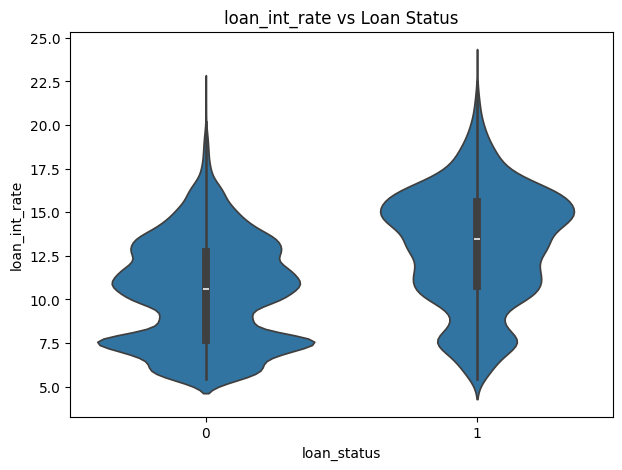

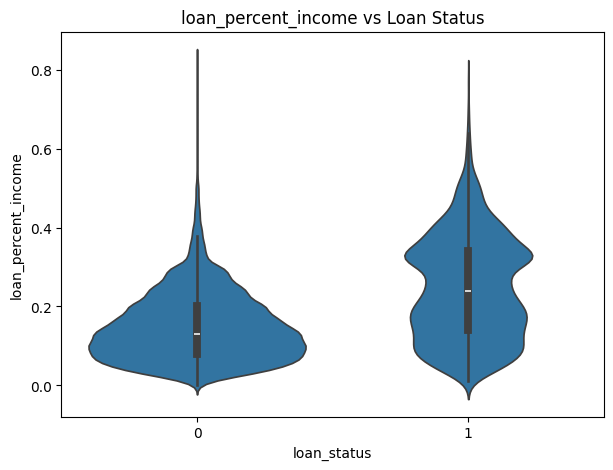

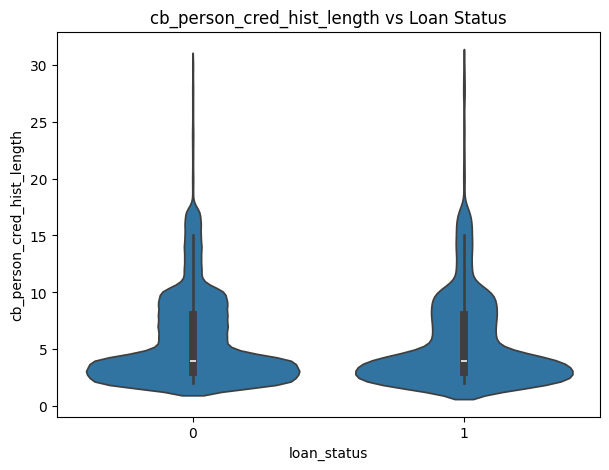

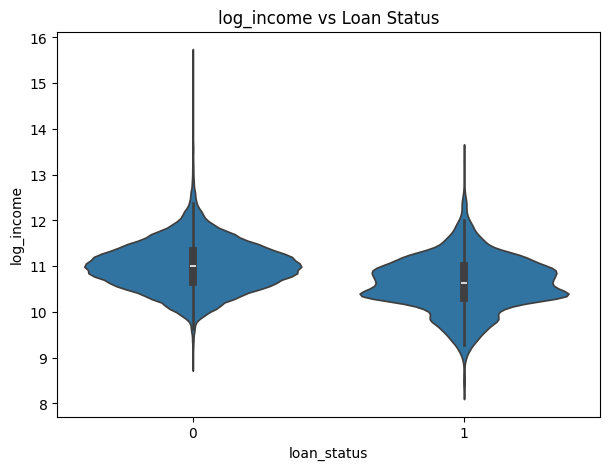

<Figure size 700x500 with 0 Axes>

In [17]:

df_relat = df.copy()
df_relat['log_income'] = np.log1p(df['person_income'])
num_feature_dist_relat = num_feature_dist + ['log_income']

for col in num_feature_dist_relat:
    if col == 'person_income' :
        continue
    sns.violinplot(
        data=df_relat,
        x='loan_status',
        y=col,
        inner='box'
    )
    plt.title(f'{col} vs Loan Status')
    plt.show()
    plt.figure(figsize=(7, 5))


  

## Interpretation Relation Numerical Features with Target
1. **Person Age** = The shapes of the two violin plots are nearly identical both have medians in the 25–27 range, with the majority of data concentrated between 20 and 30. Group 0 has a longer tail (extending to 140) compared to Group 1 (72), but this is primarily due to the much larger volume of data in Group 0 (an imbalance) rather than a genuine signal. Conclusion: it is not a strong differentiator.
2. **person_emp_length** : Their shapes are similar, except that one is more inflated; however, my outlier is clearly visible at 140+. Conclusion: the distinguishing factor is very weak.
3. **loan_amnt** = The shapes of the two violins are similar, with the median of status 1 being slightly higher. Due to this strong resemblance, the distinguishing feature is weak when considered in isolation.
4. **loan_init_rate** : The median for status 1 is higher (13 vs 10.5), with a wider spread at higher interest rates. Conclusion: a strong differentiator which makes sense, as riskier loans typically carry higher interest rates (though be wary of potential data leakage, as the interest rate might be determined based on a risk status already known to the lender).
5. **loan_percent_income** : The violin plot for status 1 clearly shifts upwards (median 0.2 vs 0.15) and shows greater bulging at higher ratios. Conclusion: a strong differentiator—high loan-to-income ratios are strongly associated with default. 
6. **cb_person** : The shapes and medians of the two violins are nearly identical. Conclusion: the distinguishing factor is very weak and almost uninformative on its own.
7. **log_income** = The median income for status 0 (11.0) is slightly higher than for status 1 (10.7); the distribution for status 1 is shifted slightly toward lower income levels and appears somewhat bimodal. There is significant overlap between the two groups. Conclusion: lower income is associated with default, but it is not a sharp, standalone differentiator.

# Compare Categorical Features VS Target (loan_status)

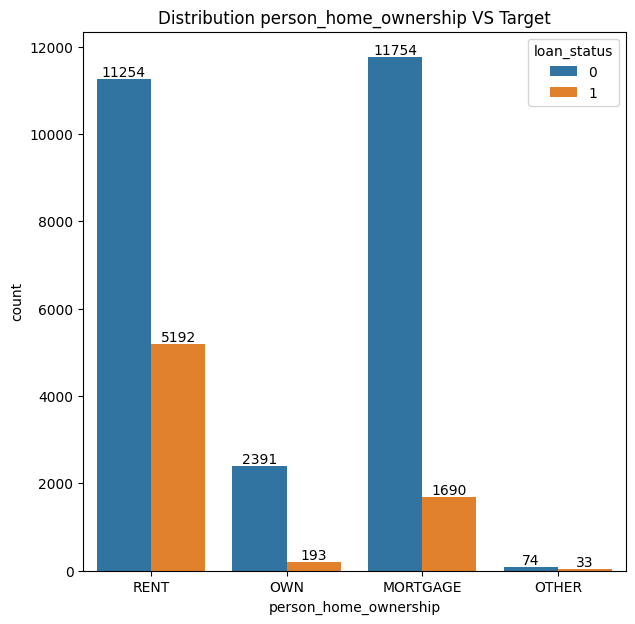

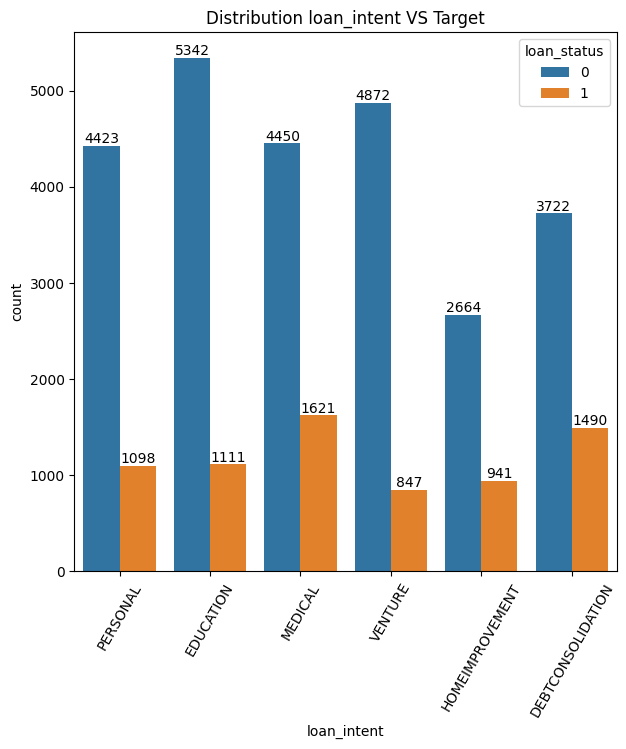

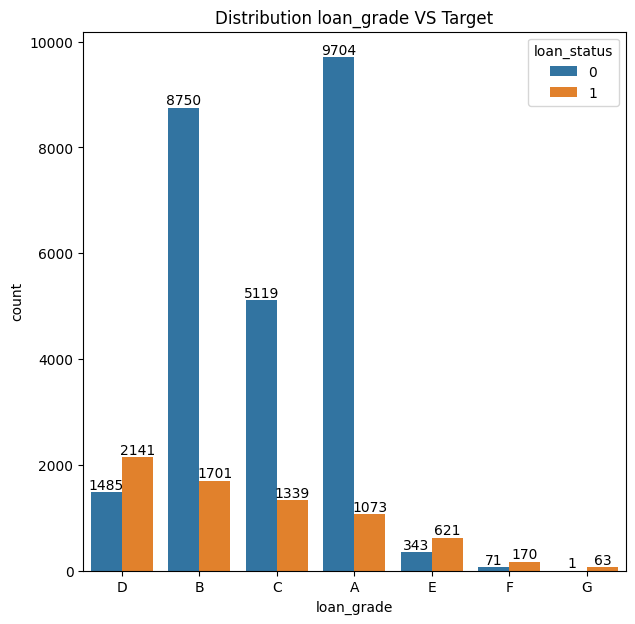

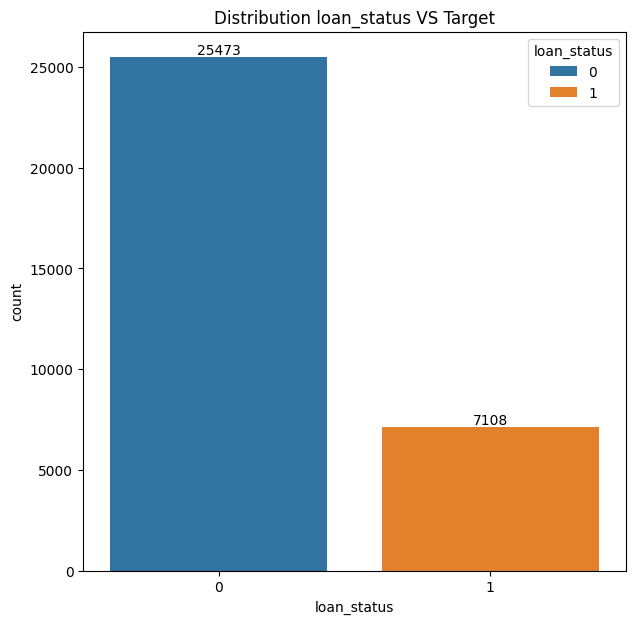

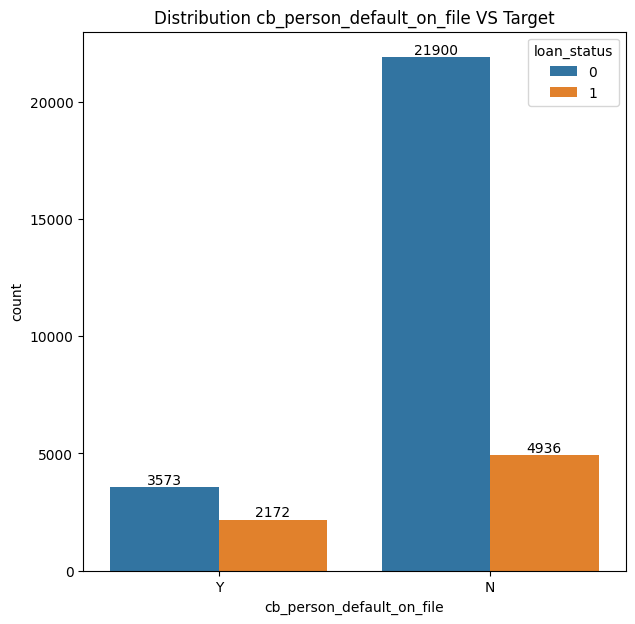

In [18]:
for feature_cat_sec in cat_feature_dist :
    plt.figure(figsize=(7,7))
    ax = sns.countplot(
        data=df,
        x= feature_cat_sec,
        hue= df['loan_status']
    )
    for containers in ax.containers :
        ax.bar_label(containers)
    plt.title(f"Distribution {feature_cat_sec} VS Target")
    if feature_cat_sec == 'loan_intent' :
        plt.xticks(rotation=60)
    plt.show()

### Interpretation of Categorical Distribution vs Target
We can see if our data leans more towards 0 for loan_status which is good because 0 loan_status is mean the client through the requirment or paying theri debt. But we still consider about imbalance data.

# Rate Categorical


Default Rate Based on person_home_ownership
person_home_ownership
RENT        31.569987
OTHER       30.841121
MORTGAGE    12.570663
OWN          7.469040
Name: loan_status, dtype: float64


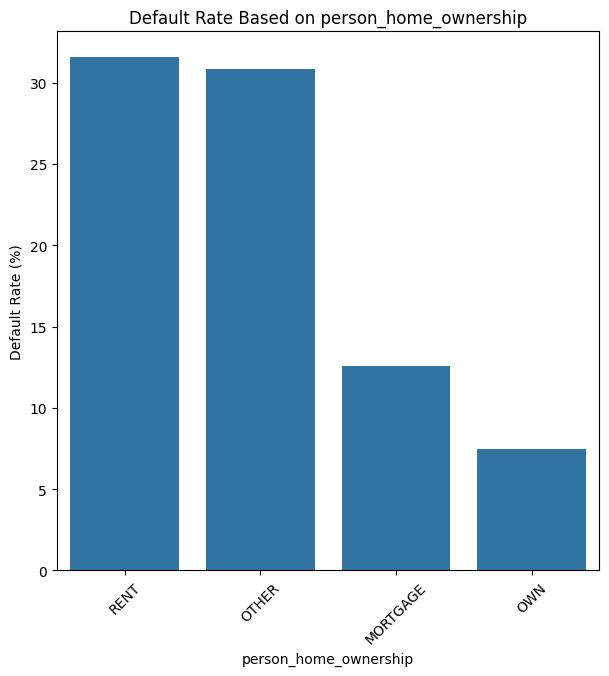


Default Rate Based on loan_intent
loan_intent
DEBTCONSOLIDATION    28.587874
MEDICAL              26.700708
HOMEIMPROVEMENT      26.102635
PERSONAL             19.887702
EDUCATION            17.216798
VENTURE              14.810282
Name: loan_status, dtype: float64


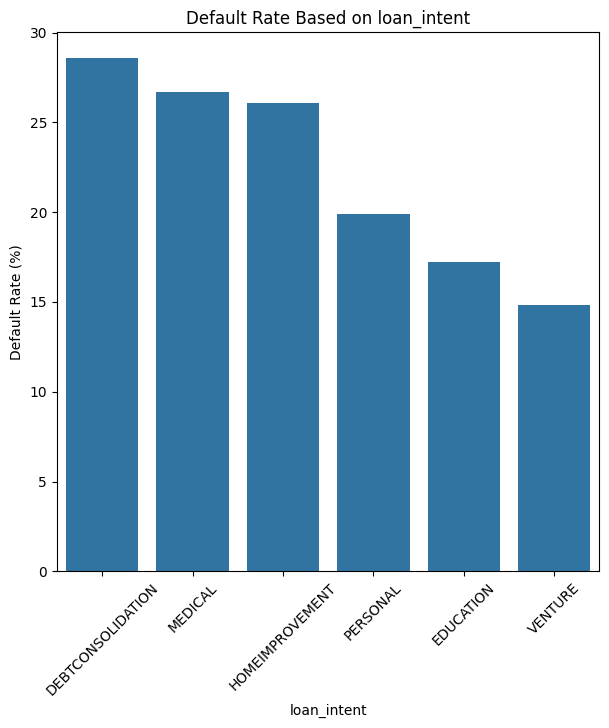


Default Rate Based on loan_grade
loan_grade
G    98.437500
F    70.539419
E    64.419087
D    59.045780
C    20.733973
B    16.275954
A     9.956389
Name: loan_status, dtype: float64


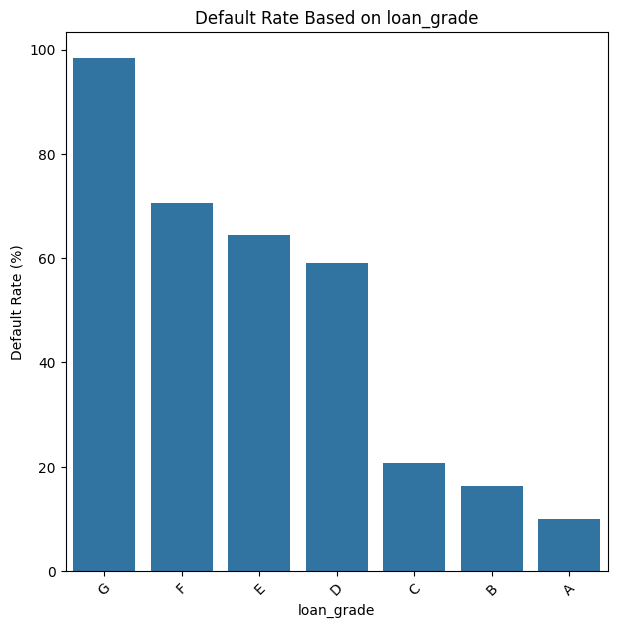


Default Rate Based on cb_person_default_on_file
cb_person_default_on_file
Y    37.806789
N    18.393203
Name: loan_status, dtype: float64


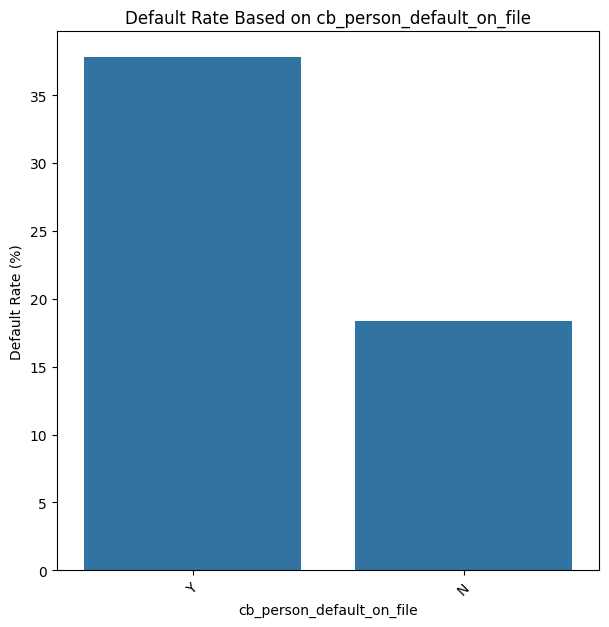

In [19]:
for col in cat_feature_dist :
    if col == 'loan_status' :
        continue
    default_rate = (
        df.groupby(col)['loan_status']
        .mean()
        .mul(100)
        .sort_values(ascending=False)
        )
    print(f'\nDefault Rate Based on {col}')
    print(default_rate)

    plt.figure(figsize=(7,7))
    sns.barplot(
        x = default_rate.index,
        y = default_rate.values
    )
    plt.title(f'Default Rate Based on {col}')
    plt.xlabel(col)
    plt.ylabel('Default Rate (%)')
    plt.xticks(rotation=45)
    plt.show()

## Interpretation Rate Categorical
1. **person_home_ownership** : A clear gap is evident between the categories: renters (RENT, 31.6%) and the "OTHER" category (30.8%) exhibit significantly higher default rates compared to those with a mortgage (MORTGAGE, 12.6%) and, even more so, those who own their homes outright (OWN, 7.5%). This pattern makes business sense individuals who do not yet own property (renters) tend to have less stable financial situations than homeowners. Conclusion: this feature is a strong differentiator.
2. **loan_intent** :    There is a fairly clear gradation: loans for debt consolidation (28.6%) and medical expenses (26.7%) carry the highest default risk—which makes sense, as these are often taken out when the borrower is already under financial strain. Conversely, loans for business ventures (14.8%) and education (17.2%) carry lower risk, likely because borrowers seeking funds for these purposes tend to have more structured financial plans. Conclusion: it is a moderate differentiator—there is a logical ranking, but the range (14.8%–28.6%) is not as extreme as that observed with home ownership.
3. **loan_grade** :This is the strongest differentiator among all categorical features—and perhaps the strongest in the entire dataset—showing a nearly perfect, monotonically increasing pattern from grade A to G: A (10.0%) → B (16.3%) → C (20.7%) → D (59.0%) → E (64.4%) → F (70.5%) → G (98.4%, almost all defaults). 
4. **cb_person_on_file** : Individuals with a prior history of default (Y) exhibit a current default rate that is twice as high (37.8%) compared to those without such a history (N, 18.4%). This pattern aligns with the general principle of credit scoring: past history is a strong predictor of future behavior. Conclusion: a strong differentiator.

# Corr map for numerical data

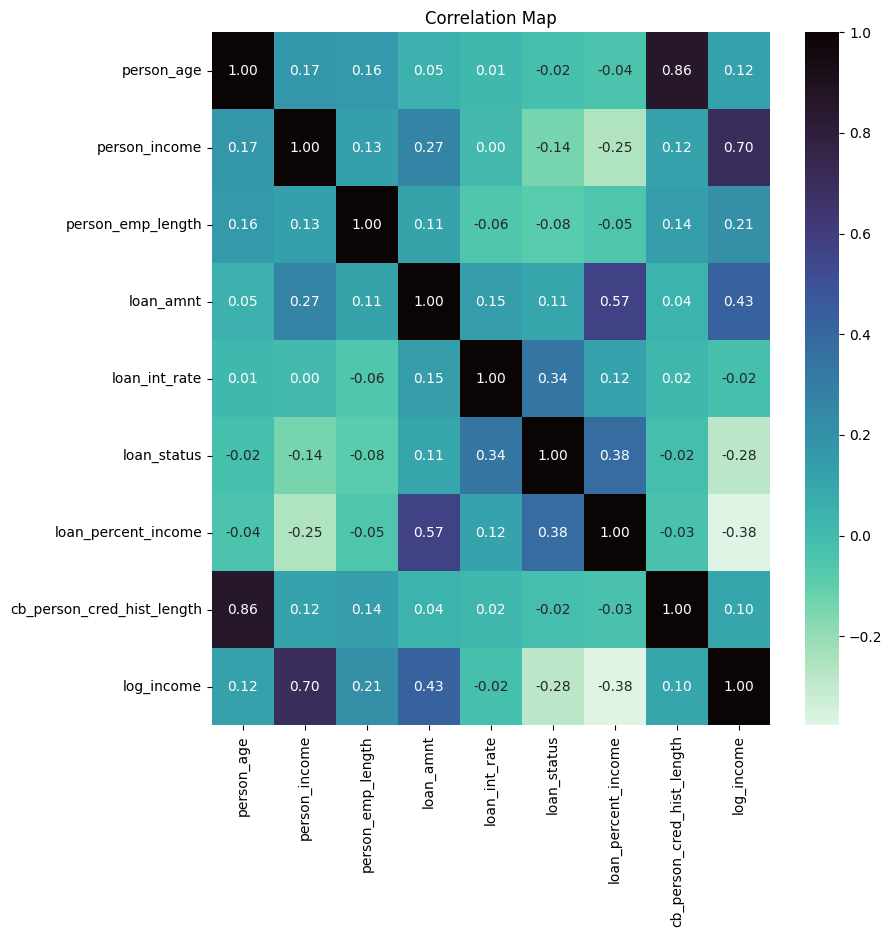

In [20]:
corr_df = df_relat.select_dtypes(include='number').copy()

corr = corr_df.corr()

plt.figure(figsize=(9,9))
sns.heatmap(
    corr,
    cmap='mako_r',
    annot=True,
    fmt='.2f'
)
plt.title("Correlation Map")
plt.show()

## Interpretation: Correlation Map

Based on the correlation matrix, the numerical features most strongly correlated with the target (`loan_status`) are `loan_percent_income` (r ≈ 0.38), `loan_int_rate` (r ≈ 0.34), and `loan_amnt` (r ≈ 0.11) — all showing a positive relationship, meaning higher values in these features are associated with a higher likelihood of default.
Note that this is Pearson correlation, which only captures **linear** relationships and only applies to numerical features. Categorical features (e.g. `person_home_ownership`, `loan_intent`) are not included here and would need separate methods (e.g. Chi-square test or Cramér's V) to assess their association with the target.
Even the strongest correlation here (r = 0.38) is only moderate — no single feature dominates, so the model will likely need to combine multiple features to predict default effectively.

# Chi Squared to check (Is there a relationship between the features and the target?)

In [21]:
from scipy.stats import chi2_contingency

result_chi = []

feature_chi = cat_feature_dist.copy()
feature_chi.remove('loan_status')

for feature in feature_chi :
    table = pd.crosstab(df[feature], df['loan_status'])

    chi_stats, p_value, dof, expected = chi2_contingency(table)
    result_chi.append({
        'feature' : feature,
        'chi2_squared' : chi_stats,
        'P value' : p_value,
        'dof' : dof
    })

df_result_chi = pd.DataFrame(result_chi)
df_result_chi = df_result_chi.sort_values('P value')

alpha = 0.05

df_result_chi['significant'] = df_result_chi['P value'] < alpha
print(df_result_chi)
 

                     feature  chi2_squared        P value  dof  significant
0      person_home_ownership   1907.980698   0.000000e+00    3         True
2                 loan_grade   5609.184187   0.000000e+00    6         True
3  cb_person_default_on_file   1044.439595  3.934660e-229    1         True
1                loan_intent    520.511561  2.980682e-110    5         True


# Interpretation Chi Squared
Every feature has Significante or P value < alpha but we but we should not immediately conclude if  `loan_grade` has a stronger relationship than `person_home_ownership` because its p-value is smaller

# Cramer's V (to find out how strong the relationship is.)

In [22]:
result_cramers = []

for feature in feature_chi:
    table = pd.crosstab(df[feature], df['loan_status'])

    chi2, p_value, dof, expected = chi2_contingency(table)

    n = table.sum().sum()
    r, k = table.shape

    cramers_v = np.sqrt(
        chi2 / (n * min(r - 1, k - 1))
    )

    result_cramers.append({
        'feature': feature,
        'chi2_squared': chi2,
        'P value': p_value,
        "Cramer's V": cramers_v
    })

df_result_cramers = pd.DataFrame(result_cramers)

df_result_cramers = df_result_cramers.sort_values(
    "Cramer's V",
    ascending=False
)

print(df_result_cramers)

                     feature  chi2_squared        P value  Cramer's V
2                 loan_grade   5609.184187   0.000000e+00    0.414923
0      person_home_ownership   1907.980698   0.000000e+00    0.241994
3  cb_person_default_on_file   1044.439595  3.934660e-229    0.179044
1                loan_intent    520.511561  2.980682e-110    0.126396


## Interpretation Cramer's V
It turns out to be true that `loan_grade`(0.41) has the closest relationship with the target.

# Data Validation

In [23]:
df[df['person_age'] > 100]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
81,144,250000,RENT,4.0,VENTURE,C,4800,13.57,0,0.02,N,3
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,0,0.03,N,2
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.25,0,0.25,N,3
747,123,78000,RENT,7.0,VENTURE,B,20000,NaN,0,0.26,N,4
32297,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.73,0,0.00,N,25


In [24]:
df[df['person_age'] < df['person_emp_length']]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
210,21,192000,MORTGAGE,123.0,VENTURE,A,20000,6.54,0,0.10,N,4


In [25]:
before = len(df)

# Remove invalid age
df = df[df['person_age'] <= 100]

# Remove invalid employment length
df = df[
    df['person_emp_length'].isna() |
    (df['person_emp_length'] <= df['person_age'])
]

after = len(df)

print(f"Data sebelum : {before}")
print(f"Data sesudah : {after}")
print(f"Data dibuang : {before - after}")

Data sebelum : 32581
Data sesudah : 32574
Data dibuang : 7


In [26]:
df[df['person_age'] > 100]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length


In [27]:
df[df['person_age'] < df['person_emp_length']]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length


# Splitting Data

In [28]:
from sklearn.model_selection import train_test_split

df = df.drop_duplicates().reset_index(drop=True)

X = df.drop(columns='loan_status')
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.2,
    random_state=42,
    stratify= y
)

print("Splitting Data Success")

Splitting Data Success


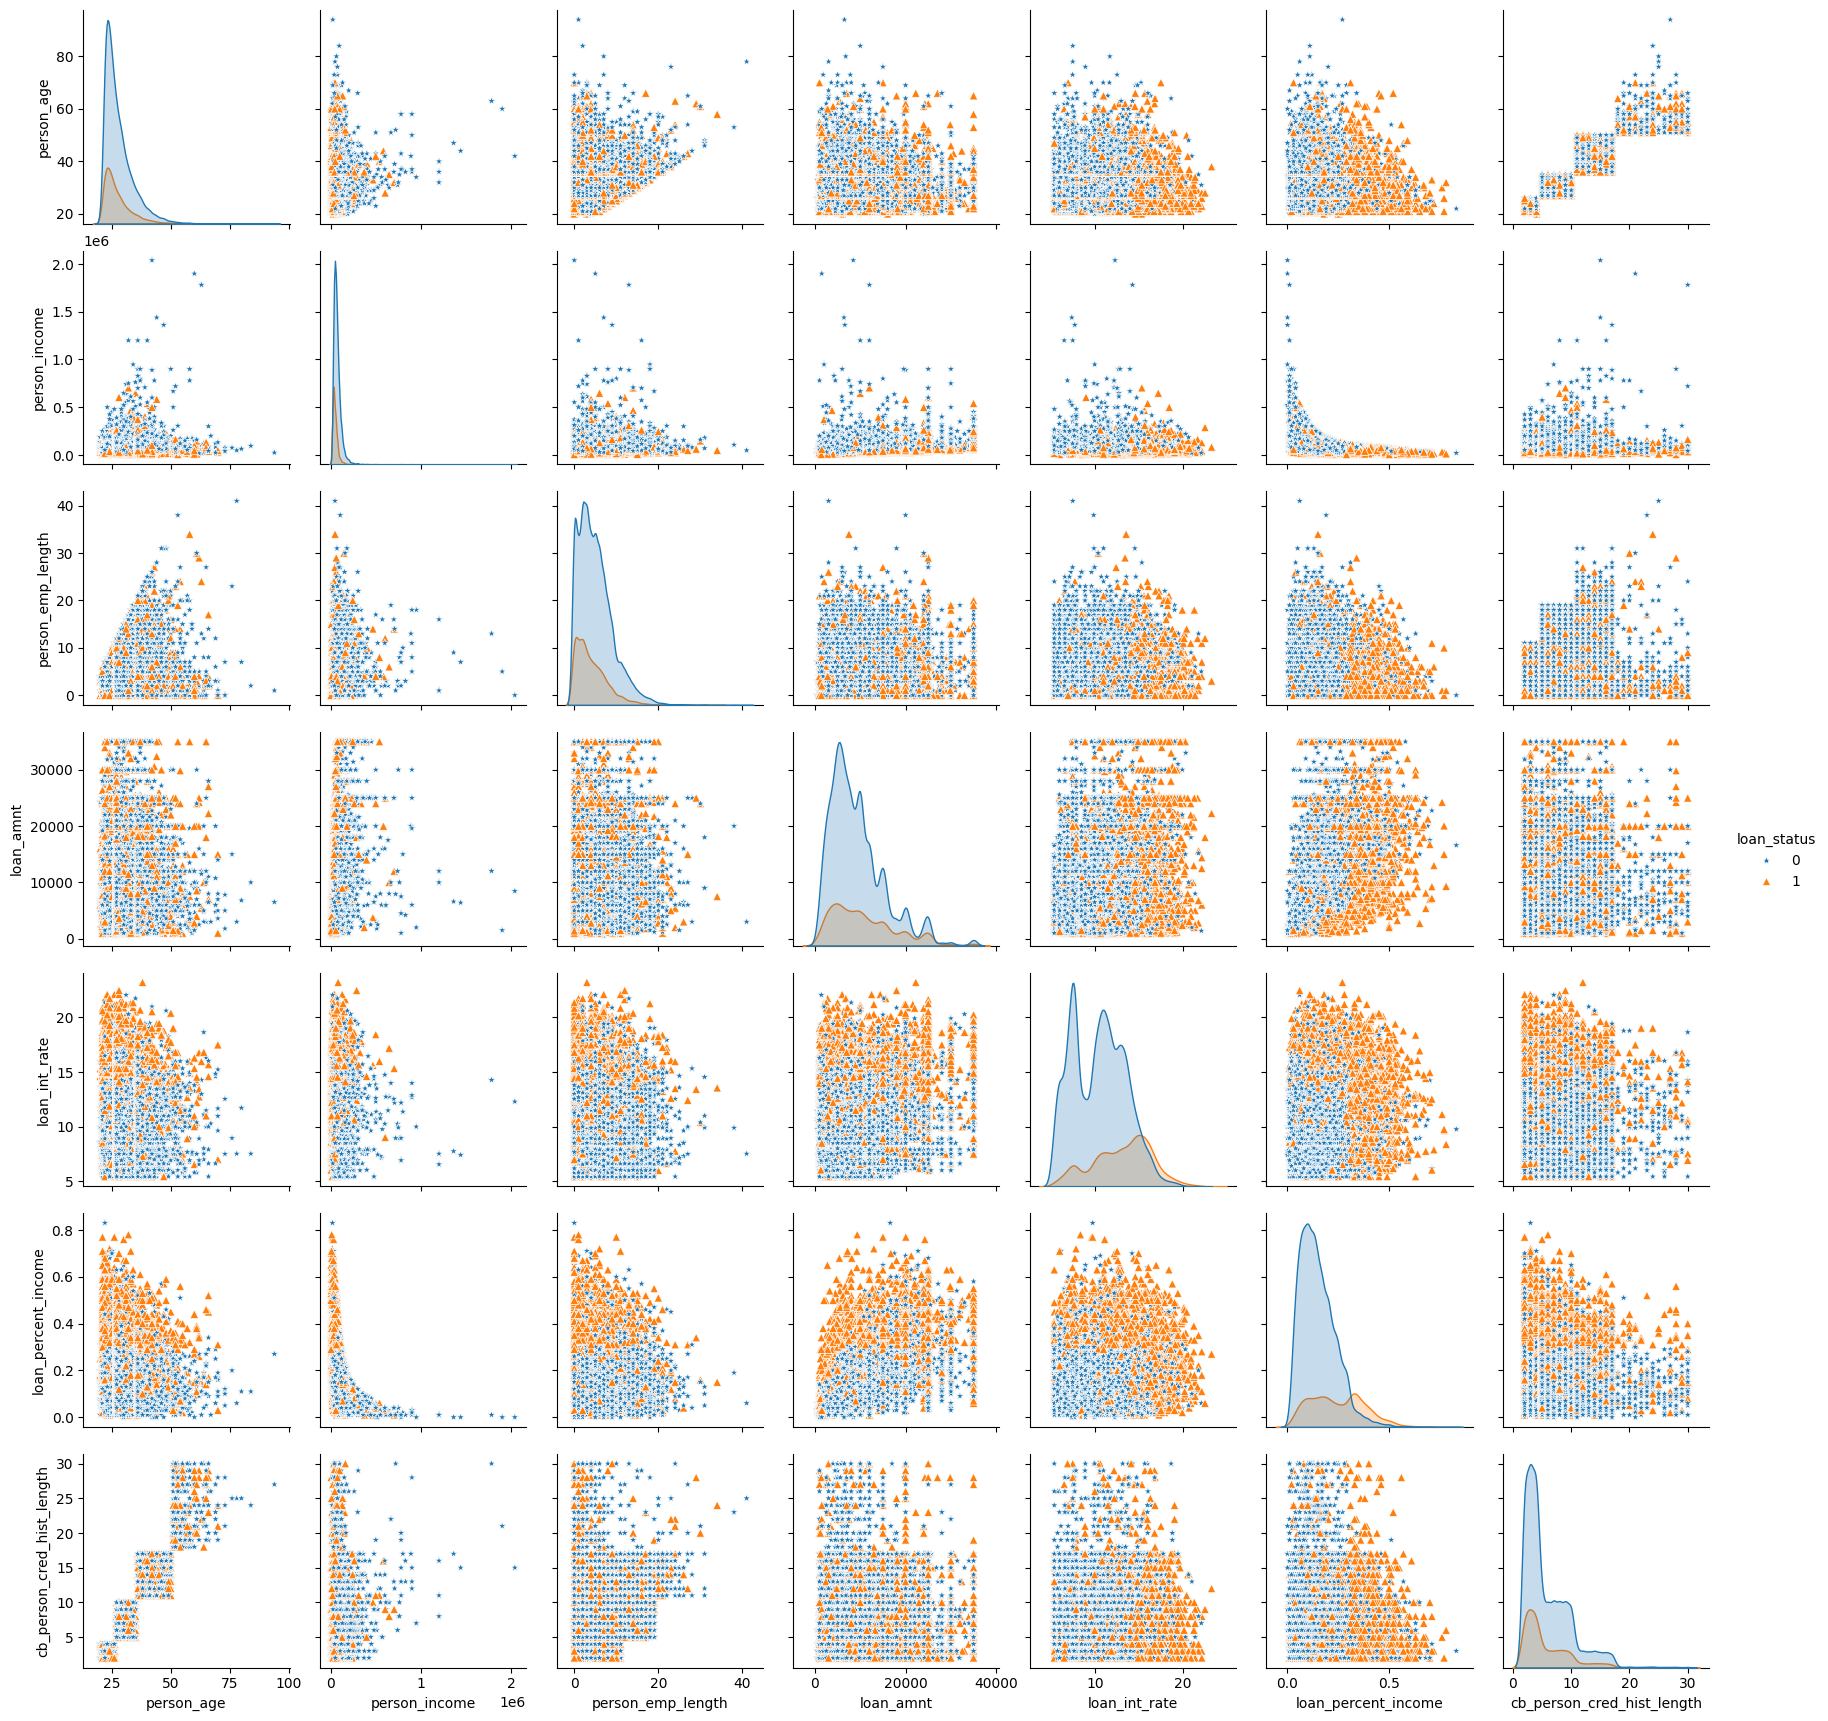

In [29]:
plot_data = pd.concat([X, y], axis=1)

sns.pairplot(
    data=plot_data,
    hue='loan_status',
    markers=['*', '^']
)

plt.show()

# Handling Missing Value with Simple Imputer

In [30]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

numerical_features = num_feature_dist.copy()
categorical_features = cat_feature_dist.copy()
categorical_features.remove('loan_status')

numerical_imputer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_imputer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])  

preprocessor = ColumnTransformer([
    ('numerical', numerical_imputer, numerical_features),
    ('categorical', categorical_imputer, categorical_features)
])

X_train_processed= preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print('Handling Missing Value Success')

Handling Missing Value Success


# Train Baseline Model

In [31]:
from xgboost import XGBClassifier

xgb_model_baseline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=42))
])

xgb_model_baseline.fit(X_train, y_train)
print('Training Baseline Model Success')

Training Baseline Model Success


# Train Imbalance

In [32]:
from xgboost import XGBClassifier

scale_pos_weight = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
    
)

print(f'Scale pos weight : {scale_pos_weight:.4f}')

xgb_model_imbalance = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        random_state = 42,
        scale_pos_weight = scale_pos_weight
    ))
])

xgb_model_imbalance.fit(X_train, y_train)
print('Training Baseline Model with imbalance Success')

Scale pos weight : 3.5737
Training Baseline Model with imbalance Success


# Functions Cross - Validation

In [33]:
from sklearn.model_selection import StratifiedKFold, cross_validate

def cross_validate_train(model, X_train, y_train) : 
    cv = StratifiedKFold(
    n_splits= 5,
    random_state= 42,
    shuffle= True
    )

    scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
    }

    cv_result = cross_validate(
        model,
        X_train,
        y_train,
        cv = cv,
        n_jobs=-1,
        scoring=scoring
    )

    result = {}

    for metric in scoring :
        scores  = cv_result[f'test_{metric}']

        result[metric.upper()] = {
            'mean' : scores.mean(),
            'std' : scores.std()
        }

    return result

# Function Evaluation Model

In [34]:
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
def evaluate_base(model, X_test, y_test) :
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]

    result_evaluate = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision' : precision_score(y_test, y_pred),
        'Recall' : recall_score(y_test, y_pred),
        'F1' : f1_score(y_test, y_pred),
        'ROC-AUC' : roc_auc_score(y_test, y_proba)
    }
    return result_evaluate

# Evaluate Base Model

In [35]:
baseline_evaluate = evaluate_base(
    xgb_model_baseline,
    X_test,
    y_test
)

for metric, value in baseline_evaluate.items() :
    print(f'{metric} : {value:.2%}')

Accuracy : 92.74%
Precision : 92.66%
Recall : 72.56%
F1 : 81.39%
ROC-AUC : 93.10%


# Interpretation Evaluate Model Baseline
The baseline XGBoost model achieved an accuracy of 92.74%, precision of 92.66%, recall of 72.56%, F1-score of 81.39%, and ROC-AUC of 93.10%. These results indicate that the model possesses strong classification capabilities, particularly in generating accurate default predictions and distinguishing between defaulting and non-defaulting customers. However, the recall of 72.56% suggests that some default cases remain undetected. Therefore, the next phase could focus on addressing class imbalance and model tuning to determine whether the model's ability to detect default cases can be improved.

# Evaluate CV Baseline

In [36]:
cv_baseline_evaluate = cross_validate_train(
    xgb_model_baseline,
    X_train,
    y_train
)

for metric, values in cv_baseline_evaluate.items() :
    print(
        f'{metric:<10} : '
        f'{values['mean']:.2%} +- {values['std']:.2%}'
    )

ACCURACY   : 92.41% +- 0.51%
PRECISION  : 91.01% +- 2.89%
RECALL     : 72.55% +- 1.29%
F1         : 80.70% +- 1.08%
ROC_AUC    : 92.87% +- 0.62%


# Interpretation CV
Based on the 5-fold cross-validation results, the baseline model achieved an accuracy of 92.41% ± 0.51%, precision of 91.01% ± 2.89%, recall of 72.55% ± 1.29%, F1-score of 80.70% ± 1.08%, and ROC-AUC of 92.87% ± 0.62%. The difference between the cross-validation results and the test set evaluation indicates performance variation when the model is tested on different data subsets. The relatively low standard deviation values ​​across most metrics suggest that the model's performance tends to be consistent across folds.

# Imbalance Evaluate

In [58]:
imbalance_evaluate = cross_validate_train(
    xgb_model_imbalance,
    X_train,
    y_train
)

for metric, values in imbalance_evaluate.items() :
    print(
        f'{metric:<10}'
        f'{values['mean']:.2%} +- {values['std']:.2%}'
    )

ACCURACY  91.41% +- 0.47%
PRECISION 83.37% +- 1.75%
RECALL    75.86% +- 0.90%
F1        79.43% +- 0.97%
ROC_AUC   92.73% +- 0.50%


# Hyperparameter Tuning

In [38]:
def get_params() :
    return {
        'classifier__n_estimators' : [100,200,300],
        'classifier__max_depth': [3,4,5],
        'classifier__learning_rate':[0.01, 0.02,0.03],
        'classifier__subsample':[0.7,0.8,0.9],
        'classifier__colsample_bytree' : [0.7, 0.8, 0.9],
        'classifier__min_child_weight' : [1, 3, 5],
        'classifier__gamma' : [0, 0.01, 0.03],
        'classifier__reg_alpha' : [0, 0.01, 0.03],
        'classifier__reg_lambda' : [1, 1.5, 2]
    }

In [39]:
def create_cv_strategy(n_splits=5, random_state= 42):
    return StratifiedKFold(
        n_splits= n_splits,
        random_state= random_state,
        shuffle= True
    )

In [40]:
from sklearn.model_selection import RandomizedSearchCV

def tune_xgb_model (
   model,
   X_train,
   y_train,
   params_distribution,
   cv,
   n_iter = 20,
   scoring= 'f1',
   random_state = 42,
   n_jobs = -1
): 
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions= params_distribution,
        n_iter=n_iter,
        scoring=scoring,
        cv= cv,
        random_state= random_state,
        n_jobs= n_jobs,
        verbose=1
    )

    random_search.fit(X_train, y_train)
    return random_search

In [41]:
def display_tuning_results(random_search):
    
    print('===== Hyperparameter Tuning Results =====')
    
    print('\nBest Parameters:')
    
    for parameter, value in random_search.best_params_.items():
        print(f'{parameter:<40}: {value}')
    
    print(
        f'\nBest CV Score: '
        f'{random_search.best_score_:.2%}'
    )

In [42]:
params_dist = get_params()

cv = create_cv_strategy(
    n_splits=5,
    random_state=42,
    
)

xgb_random_search = tune_xgb_model(
    model= xgb_model_imbalance,
    X_train= X_train,
    y_train= y_train,
    params_distribution= params_dist,
    cv=cv,
    n_iter=20,
    scoring='f1',
    random_state=42,
    n_jobs= -1
    
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [43]:
display_tuning_results(xgb_random_search)
xgb_model_tuned = xgb_random_search.best_estimator_

===== Hyperparameter Tuning Results =====

Best Parameters:
classifier__subsample                   : 0.7
classifier__reg_lambda                  : 2
classifier__reg_alpha                   : 0.03
classifier__n_estimators                : 300
classifier__min_child_weight            : 1
classifier__max_depth                   : 5
classifier__learning_rate               : 0.03
classifier__gamma                       : 0.03
classifier__colsample_bytree            : 0.7

Best CV Score: 77.91%


In [44]:
hyper_tuned_evaluate = evaluate_base(
    xgb_model_tuned,
    X_test,
    y_test
)

for metric, value in hyper_tuned_evaluate.items() :
    print(f'{metric} : {value:.2%}')

Accuracy : 89.78%
Precision : 76.03%
Recall : 77.80%
F1 : 76.90%
ROC-AUC : 93.12%


# Interpretation Hyper Paramters Tuning
Hyperparameter tuning yielded a configuration with a CV F1 score of 77.91%. On the test set, the model achieved a Recall of 77.80%, an improvement over the baseline of 72.56%. However, this increase in Recall was accompanied by a decline in Precision—from 92.66% to 76.03%—and in the F1 Score—from 81.39% to 76.90%. The ROC-AUC remained relatively stable at around 93%, indicating that the tuning did not significantly alter the model's discriminative capability.

# Confusing Matrix

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_confusion_matrix(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Non-Default (0)', 'Default (1)']
    )

    disp.plot()
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('Actual Label')
    plt.show()

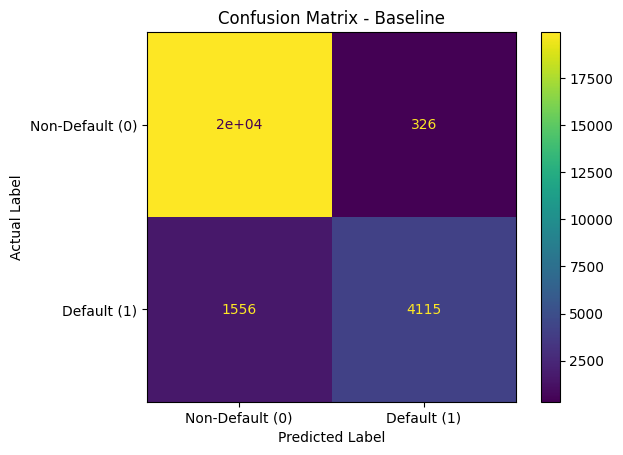

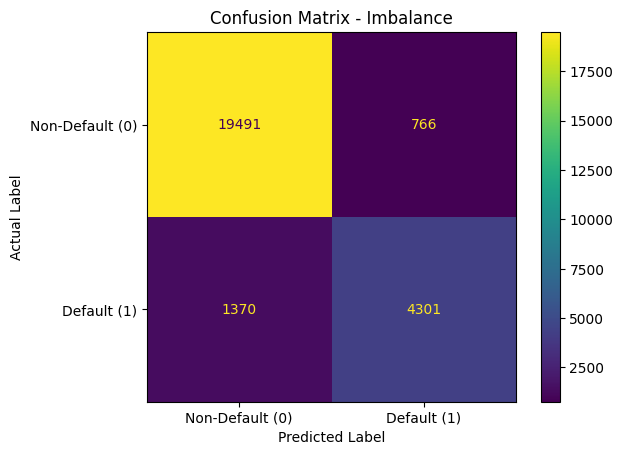

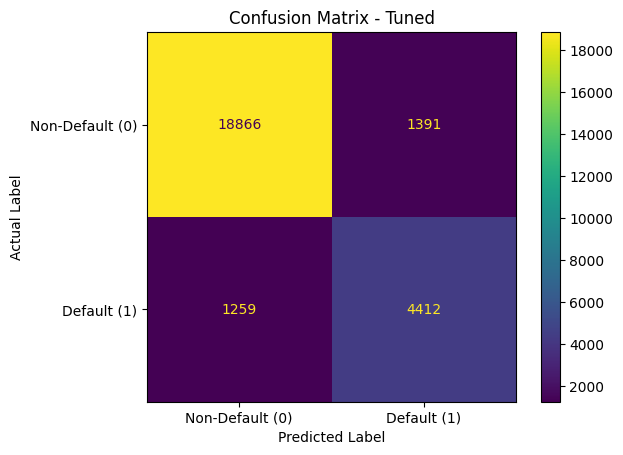

In [46]:
plot_confusion_matrix(
    xgb_model_baseline,
    X_test,
    y_test,
    'Baseline'
)

plot_confusion_matrix(
    xgb_model_imbalance,
    X_test,
    y_test,
    'Imbalance'
)

plot_confusion_matrix(
    xgb_model_tuned,
    X_test,
    y_test,
    'Tuned'
)

# ROC Curve

In [47]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

def plot_roc_curve(models, X_test, y_test):
    plt.figure(figsize=(8, 6))

    for model_name, model in models.items():
        y_proba = model.predict_proba(X_test)[:, 1]

        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc_score = roc_auc_score(y_test, y_proba)

        plt.plot(
            fpr,
            tpr,
            label=f'{model_name} (AUC = {auc_score:.2%})'
        )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle='--',
        label='Random Classifier'
    )

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve Comparison')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

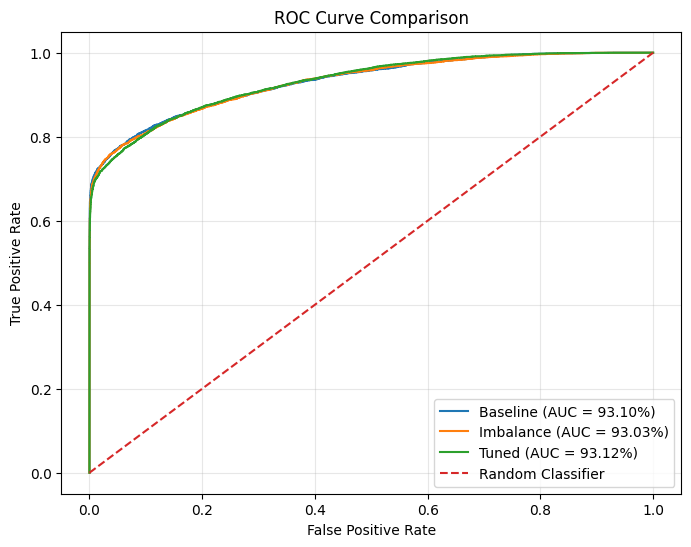

In [48]:
models = {
    'Baseline': xgb_model_baseline,
    'Imbalance': xgb_model_imbalance,
    'Tuned': xgb_model_tuned
}

plot_roc_curve(
    models,
    X_test,
    y_test
)

# Precision Recall Curve

In [49]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

def plot_precision_recall_curve(models, X_test, y_test):
    plt.figure(figsize=(8, 6))

    for model_name, model in models.items():
        y_proba = model.predict_proba(X_test)[:, 1]

        precision, recall, _ = precision_recall_curve(
            y_test,
            y_proba
        )

        plt.plot(
            recall,
            precision,
            label=model_name
        )

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve Comparison')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

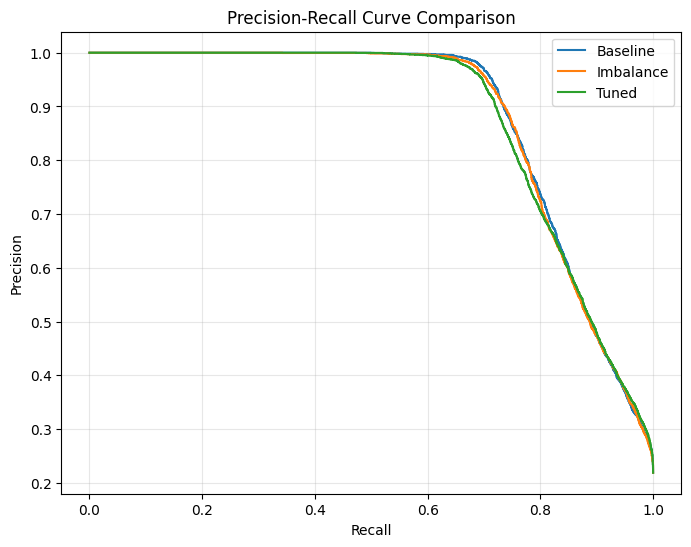

In [50]:
plot_precision_recall_curve(
    models,
    X_test,
    y_test
)

# Feature Importance

In [59]:
classifier = xgb_model_tuned.named_steps['classifier']

def get_feature_importance(model):
    preprocessor = model.named_steps['preprocessor']
    classifier = model.named_steps['classifier']

    feature_names = preprocessor.get_feature_names_out()

    importance = classifier.feature_importances_

    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance
    })

    feature_importance_df = feature_importance_df.sort_values(
        by='Importance',
        ascending=False
    )

    return feature_importance_df

In [60]:
feature_importance_df = get_feature_importance(
    xgb_model_tuned
)

display(feature_importance_df.head(15))

,Feature,Importance
5,numerical__loan_percent_income,0.087832
17,categorical__loan_grade_A,0.086412
20,categorical__loan_grade_D,0.080011
10,categorical__person_home_ownership_RENT,0.075779
4,numerical__loan_int_rate,0.066216
19,categorical__loan_grade_C,0.054445
9,categorical__person_home_ownership_OWN,0.049673
18,categorical__loan_grade_B,0.045147
1,numerical__person_income,0.042424
21,categorical__loan_grade_E,0.038741


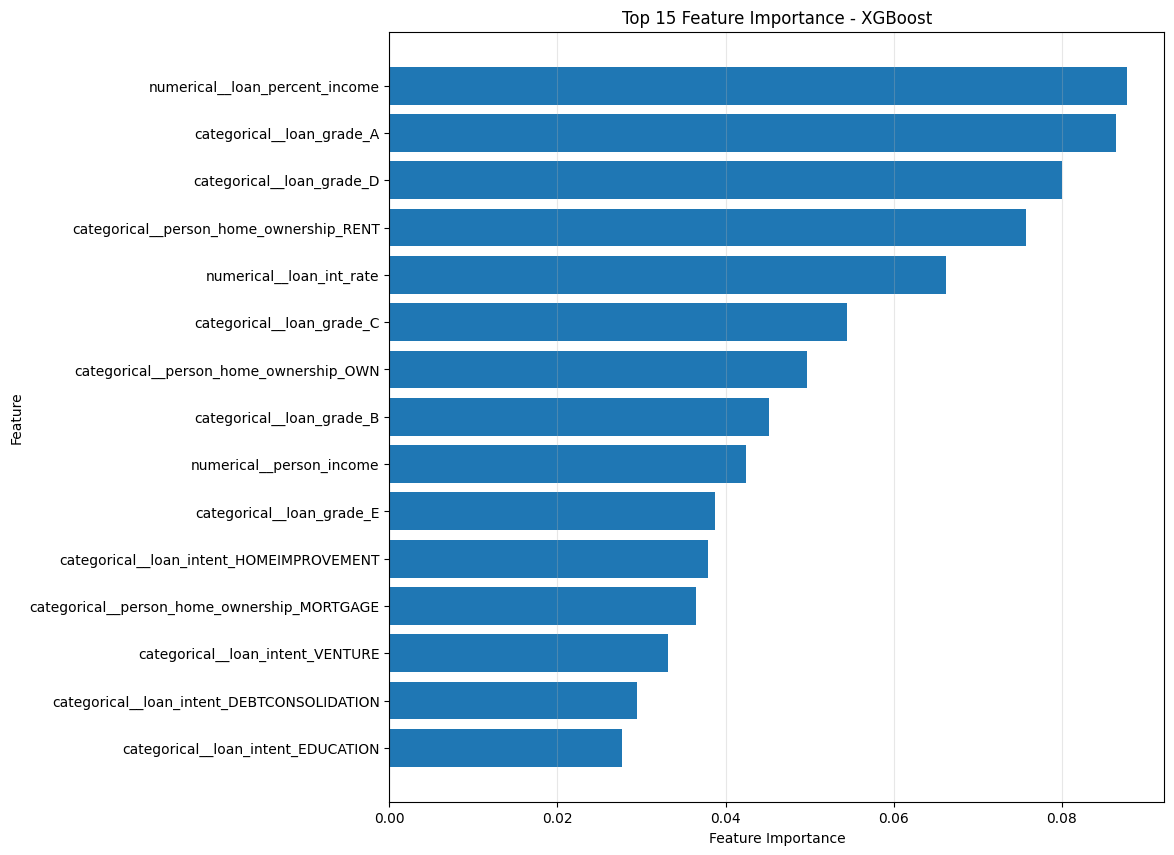

In [62]:
def plot_feature_importance(model, top_n=15):
    feature_importance_df = get_feature_importance(model)

    top_features = feature_importance_df.head(top_n)

    plt.figure(figsize=(10, 10))

    plt.barh(
        top_features['Feature'][::-1],
        top_features['Importance'][::-1]
    )

    plt.xlabel('Feature Importance')
    plt.ylabel('Feature')
    plt.title(
        f'Top {top_n} Feature Importance - XGBoost'
    )

    plt.grid(axis='x', alpha=0.3)
    plt.show()


plot_feature_importance(
    xgb_model_tuned,
    top_n=15
)
